In [21]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
!pip install mediapipe

In [23]:
import cv2
import pandas as pd
import mediapipe as mp
import numpy as np
from google.colab.patches import cv2_imshow

In [24]:
# Đặt các tham số augmentation
scale_factor = 1
translate = (0, 0)
rotation_angle = 10
horizontal_flip = False

# Đường dẫn đến file video và CSV (chỉnh sửa theo đường dẫn thực tế)
video_path = "/content/drive/MyDrive/Gym/data/check_data/check_data/barbell biceps curl_1.mp4"
csv_file = "/content/drive/MyDrive/Gym/data/Merge_data_to_csv_split/train/barbell biceps curl/barbell biceps curl_1.csv"
frame_idx = 10  # Chỉ số frame cần xử lý

In [25]:
# ------------------------------
# Các hàm hỗ trợ augmentation đã được định nghĩa
# ------------------------------

def compose_affine_transform(image_shape, scale=1.0, rotation_angle=0, horizontal_flip=False, translate=(0,0)):
    """
    Tạo ma trận biến đổi affine tổng hợp với các phép: scale, rotation quanh tâm, horizontal flip và translation.
    Các phép được kết hợp theo thứ tự: Scale -> Rotation -> Horizontal Flip -> Translation.
    """
    h, w = image_shape[:2]

    # Ma trận scale
    M_scale = np.array([
         [scale,    0, 0],
         [   0, scale, 0],
         [   0,    0, 1]
    ])

    # Ma trận xoay quanh tâm ảnh
    center = np.array([w/2, h/2])
    T1 = np.array([
         [1, 0, -center[0]],
         [0, 1, -center[1]],
         [0, 0, 1]
    ])
    T2 = np.array([
         [1, 0, center[0]],
         [0, 1, center[1]],
         [0, 0, 1]
    ])
    theta = np.deg2rad(rotation_angle)
    M_rot = np.array([
         [np.cos(theta), -np.sin(theta), 0],
         [np.sin(theta),  np.cos(theta), 0],
         [            0,              0, 1]
    ])
    M_rotation = T2 @ M_rot @ T1

    # Ma trận horizontal flip
    if horizontal_flip:
         M_flip = np.array([
              [-1, 0, w],
              [ 0, 1, 0],
              [ 0, 0, 1]
         ])
    else:
         M_flip = np.eye(3)

    # Ma trận dịch chuyển (translation)
    tx, ty = translate
    M_translate = np.array([
         [1, 0, tx],
         [0, 1, ty],
         [0, 0, 1]
    ])

    # Kết hợp các biến đổi: Translation * Flip * Rotation * Scale
    M_combined = M_translate @ M_flip @ M_rotation @ M_scale

    # Trả về ma trận 2x3 dùng cho cv2.warpAffine
    return M_combined[:2, :]

def augment_image(image, M):
    """
    Áp dụng biến đổi affine cho image sử dụng ma trận M.
    """
    h, w = image.shape[:2]
    augmented = cv2.warpAffine(image, M, (w, h))
    return augmented

def augment_landmarks(landmarks, M):
    """
    Áp dụng biến đổi affine cho landmarks (danh sách tọa độ pixel).
    landmarks: danh sách [(x, y), ...]
    """
    pts = np.array(landmarks)  # shape (N,2)
    pts_hom = np.hstack([pts, np.ones((pts.shape[0], 1))])  # chuyển sang tọa độ đồng nhất (N,3)
    transformed = (M @ pts_hom.T).T  # (N,2)
    return transformed.tolist()

# ------------------------------
# Hàm đọc landmarks từ CSV với tọa độ normalized
# ------------------------------

def read_landmarks_from_csv(csv_file, frame_idx):
    try:
        df = pd.read_csv(csv_file)
        if "Frame" not in df.columns:
            print("Lỗi: File CSV không có cột 'Frame'.")
            return []
        if frame_idx not in df["Frame"].values:
            print(f"Không có landmarks nào tại frame {frame_idx}")
            return []
        frame_data = df[df["Frame"] == frame_idx]
        landmarks = []
        # Giả sử các cột có tên: "point1_x", "point1_y", "point2_x", "point2_y", ...
        # Sắp xếp theo thứ tự cột _x để đảm bảo thứ tự landmarks
        x_cols = sorted([col for col in df.columns if col.endswith("_x")])
        for col in x_cols:
            base_name = col[:-2]  # loại bỏ "_x"
            x = frame_data[f"{base_name}_x"].values[0]
            y = frame_data[f"{base_name}_y"].values[0]
            landmarks.append((x, y))
        return landmarks
    except Exception as e:
        print(f"Lỗi khi đọc file CSV: {e}")
        return []

# ------------------------------
# Hàm lấy frame từ video theo index
# ------------------------------

def get_frame_from_video(video_path, frame_idx):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
         raise ValueError(f"Không thể lấy frame {frame_idx} từ video {video_path}")
    return frame


In [26]:
# ------------------------------
# Main: Thực hiện augmentation cho 1 frame cụ thể dựa trên index
# ------------------------------
# Lấy frame từ video
image = get_frame_from_video(video_path, frame_idx)
h, w = image.shape[:2]

# Đọc landmarks từ CSV (tọa độ normalized)
landmarks_norm = read_landmarks_from_csv(csv_file, frame_idx)
if not landmarks_norm:
    raise ValueError("Không đọc được landmarks từ CSV.")

# Chuyển đổi landmarks từ normalized sang pixel
landmarks_pixels = [(l[0] * w, l[1] * h) for l in landmarks_norm]

# Tạo ma trận biến đổi affine tổng hợp
M = compose_affine_transform(image.shape, scale=scale_factor, rotation_angle=rotation_angle,
                             horizontal_flip=horizontal_flip, translate=translate)

# Áp dụng biến đổi cho image
augmented_image = augment_image(image, M)

# Áp dụng biến đổi cho landmarks
augmented_landmarks = augment_landmarks(landmarks_pixels, M)

# Chuyển đổi landmarks đã biến đổi từ pixel về normalized (dựa trên kích thước image gốc)
aug_landmarks_norm = [(pt[0] / w, pt[1] / h) for pt in augmented_landmarks]

# Cập nhật lại CSV cho frame frame_idx
df = pd.read_csv(csv_file)
x_cols = sorted([col for col in df.columns if col.endswith("_x")])
for i, col in enumerate(x_cols):
    base = col[:-2]
    df.loc[df['Frame'] == frame_idx, f"{base}_x"] = aug_landmarks_norm[i][0]
    df.loc[df['Frame'] == frame_idx, f"{base}_y"] = aug_landmarks_norm[i][1]

augmented_csv = "augmented_landmarks.csv"
df.to_csv(augmented_csv, index=False)
print(f"Đã lưu CSV augmentation tại: {augmented_csv}")

# Lưu image đã augmentation (nếu cần)
cv2.imwrite("augmented_image.jpg", augmented_image)
print("Đã lưu image augmentation tại: augmented_image.jpg")

Đã lưu CSV augmentation tại: augmented_landmarks.csv
Đã lưu image augmentation tại: augmented_image.jpg


In [27]:
mp_pose_landmark_names = [
    "NOSE",
    "LEFT_EYE_INNER",
    "LEFT_EYE",
    "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER",
    "RIGHT_EYE",
    "RIGHT_EYE_OUTER",
    "LEFT_EAR",
    "RIGHT_EAR",
    "MOUTH_LEFT",
    "MOUTH_RIGHT",
    "LEFT_SHOULDER",
    "RIGHT_SHOULDER",
    "LEFT_ELBOW",
    "RIGHT_ELBOW",
    "LEFT_WRIST",
    "RIGHT_WRIST",
    "LEFT_PINKY",
    "RIGHT_PINKY",
    "LEFT_INDEX",
    "RIGHT_INDEX",
    "LEFT_THUMB",
    "RIGHT_THUMB",
    "LEFT_HIP",
    "RIGHT_HIP",
    "LEFT_KNEE",
    "RIGHT_KNEE",
    "LEFT_ANKLE",
    "RIGHT_ANKLE",
    "LEFT_HEEL",
    "RIGHT_HEEL",
    "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX"
]


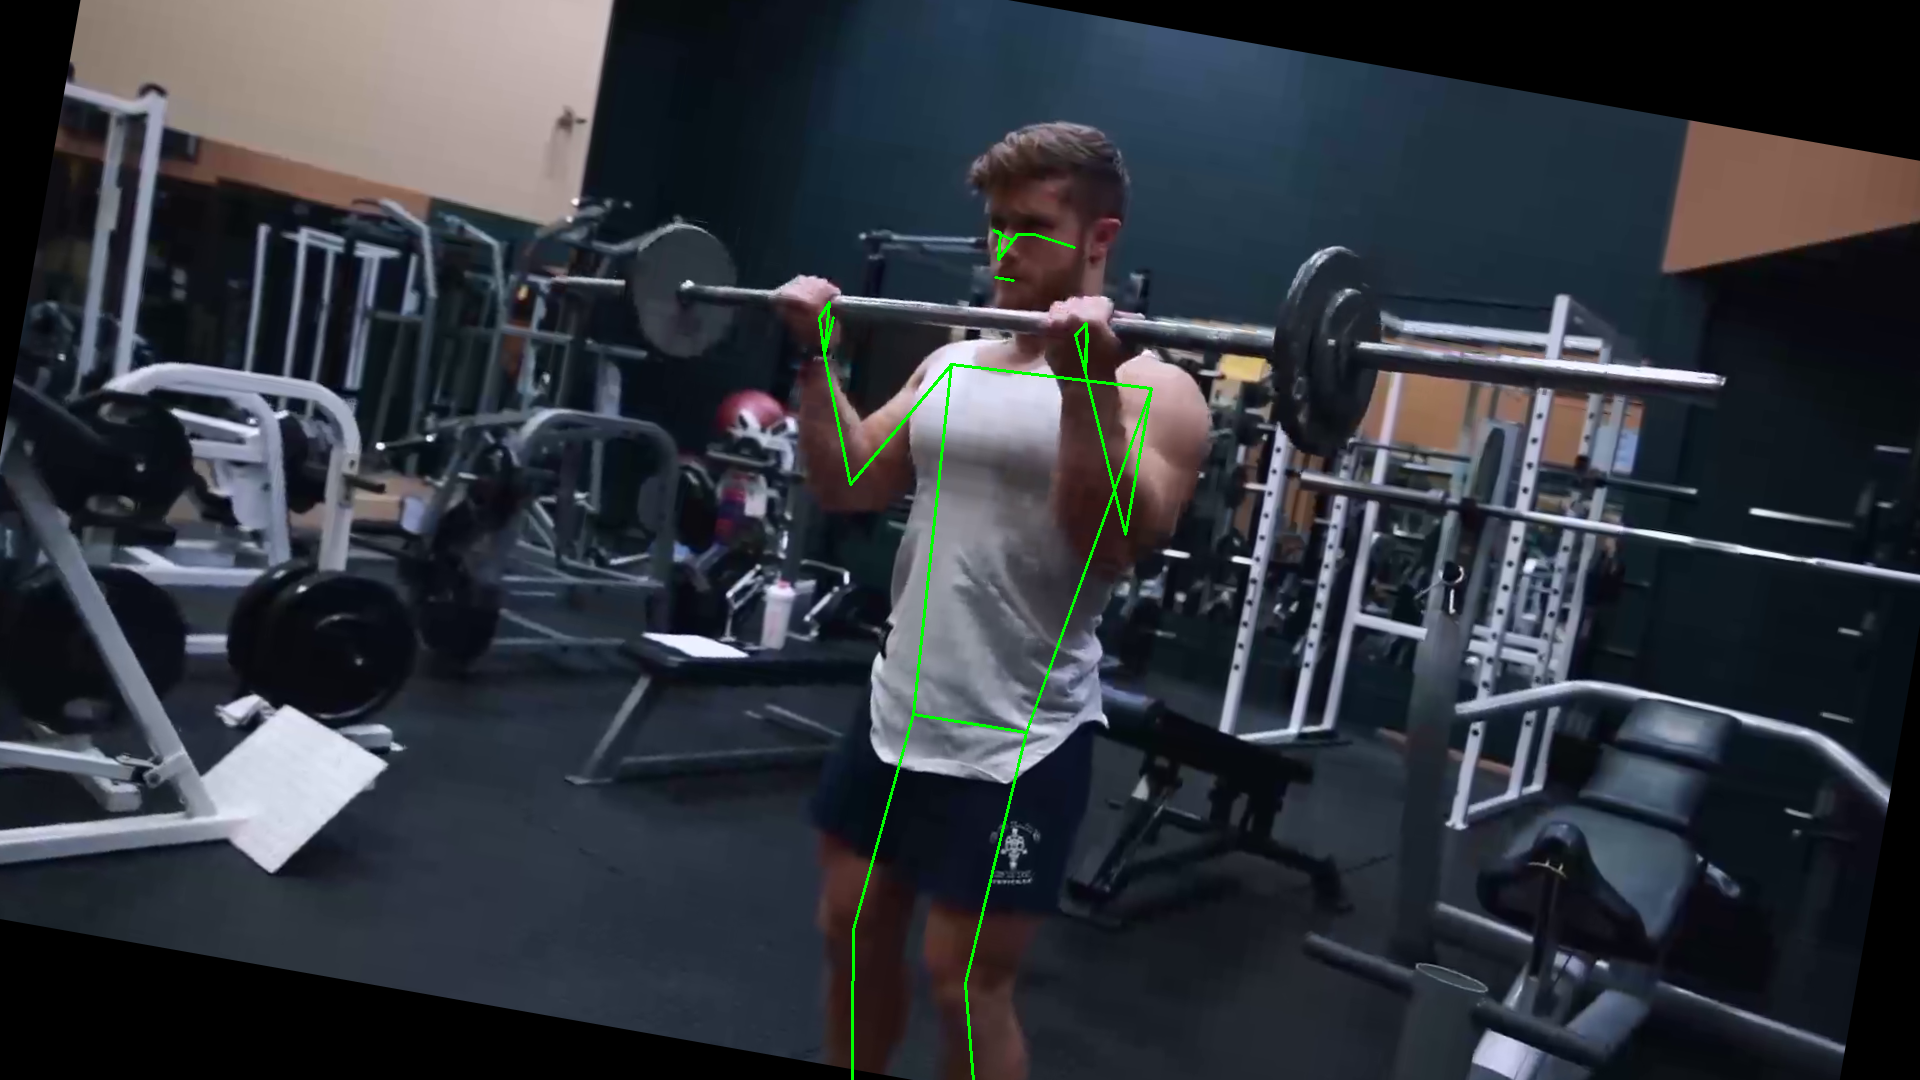

In [28]:
# Khởi tạo các kết nối của Mediapipe Pose
mp_pose = mp.solutions.pose
pose_connections = mp_pose.POSE_CONNECTIONS

def draw_skeleton(image, landmarks):
    """
    Vẽ các đường nối giữa các điểm landmarks theo cấu trúc của Mediapipe Pose.
    """
    for connection in pose_connections:
        start_idx = connection[0]
        end_idx = connection[1]
        if start_idx < len(landmarks) and end_idx < len(landmarks):
            start_landmark = landmarks[start_idx]
            end_landmark = landmarks[end_idx]
            cv2.line(image,
                     (int(start_landmark[0]), int(start_landmark[1])),
                     (int(end_landmark[0]), int(end_landmark[1])),
                     (0, 255, 0), 2)
    return image

def read_landmarks_from_csv(csv_file, frame_idx):
    df = pd.read_csv(csv_file)
    # Kiểm tra cột Frame
    if "Frame" not in df.columns:
        print("Lỗi: File CSV không có cột 'Frame'.")
        return []
    if frame_idx not in df["Frame"].values:
        print(f"Không có landmarks nào tại frame {frame_idx}")
        return []
    frame_data = df[df["Frame"] == frame_idx]

    # Đảm bảo CSV có đủ các cột x, y (hoặc z, visibility) cho 33 landmarks
    landmarks = []
    for landmark_name in mp_pose_landmark_names:
        x_col = f"{landmark_name}_x"
        y_col = f"{landmark_name}_y"
        if x_col not in frame_data.columns or y_col not in frame_data.columns:
            print(f"Lỗi: không tìm thấy cột {x_col} hoặc {y_col} trong CSV.")
            return []
        x = frame_data[x_col].values[0]
        y = frame_data[y_col].values[0]
        landmarks.append((x, y))
    return landmarks


def check_augmented_pose(aug_image, csv_file, frame_idx):
    """
    Kiểm tra pose bằng cách vẽ skeleton lên image đã augmentation
    sử dụng landmarks được đọc từ CSV đã cập nhật.
    Nếu các phép augmentation của image và CSV khớp nhau, kết quả vẽ sẽ đồng nhất.
    """
    if aug_image is None:
        print("Image không hợp lệ.")
        return

    # Đọc landmarks từ CSV (giá trị normalized)
    landmarks_norm = read_landmarks_from_csv(csv_file, frame_idx)
    if not landmarks_norm:
        print(f"Không có dữ liệu landmarks để vẽ tại frame {frame_idx}")
        return

    h, w, _ = aug_image.shape
    # Chuyển đổi từ normalized sang pixel
    scaled_landmarks = [(l[0] * w, l[1] * h) for l in landmarks_norm]

    # Vẽ skeleton
    frame_with_skeleton = draw_skeleton(aug_image.copy(), scaled_landmarks)
    cv2_imshow(frame_with_skeleton)

# Sử dụng image đã augmentation và CSV đã được cập nhật từ Cell 2
check_augmented_pose(augmented_image, augmented_csv, frame_idx)
